# Face Recognition Model

## Import Libraries

We're bringing in all the necessary tools for machine learning, data processing, and visualization. This includes scikit-learn for our Random Forest model, pandas and numpy for handling data, and matplotlib with seaborn for creating visualizations.


In [23]:
# Core data processing
import numpy as np
import pandas as pd
from pathlib import Path
import time
import json
import warnings
warnings.filterwarnings('ignore')

# Import Config for dynamic user management
import sys

# Add project root to path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import Config

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    log_loss,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Model persistence
import joblib

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

## Load Pre-Processed Features

We're loading the preprocessed features from our CSV file which contains 512-dimensional VGG16 embeddings for each image along with metadata about the user, expression type, and augmentation applied. Each user has been assigned a numeric label that we'll use for classification.

In [34]:
# Load the extracted features
csv_path = 'data/features/image_features.csv'
df = pd.read_csv(csv_path)

# Display dataset overview
display(df[['user', 'expression', 'augmentation', 'label']].head(7))

,user,expression,augmentation,label
0,damour,surprised,original,0
1,damour,surprised,rotation_15,0
2,damour,surprised,rotation_neg15,0
3,damour,surprised,horizontal_flip,0
4,damour,surprised,brightness_increase,0
5,damour,surprised,brightness_decrease,0
6,damour,surprised,grayscale,0


### Sample Images

Let's take a visual look at the original images we're working with to get a sense of the data quality and variety. This helps us see how different team members and expressions appear in our dataset.


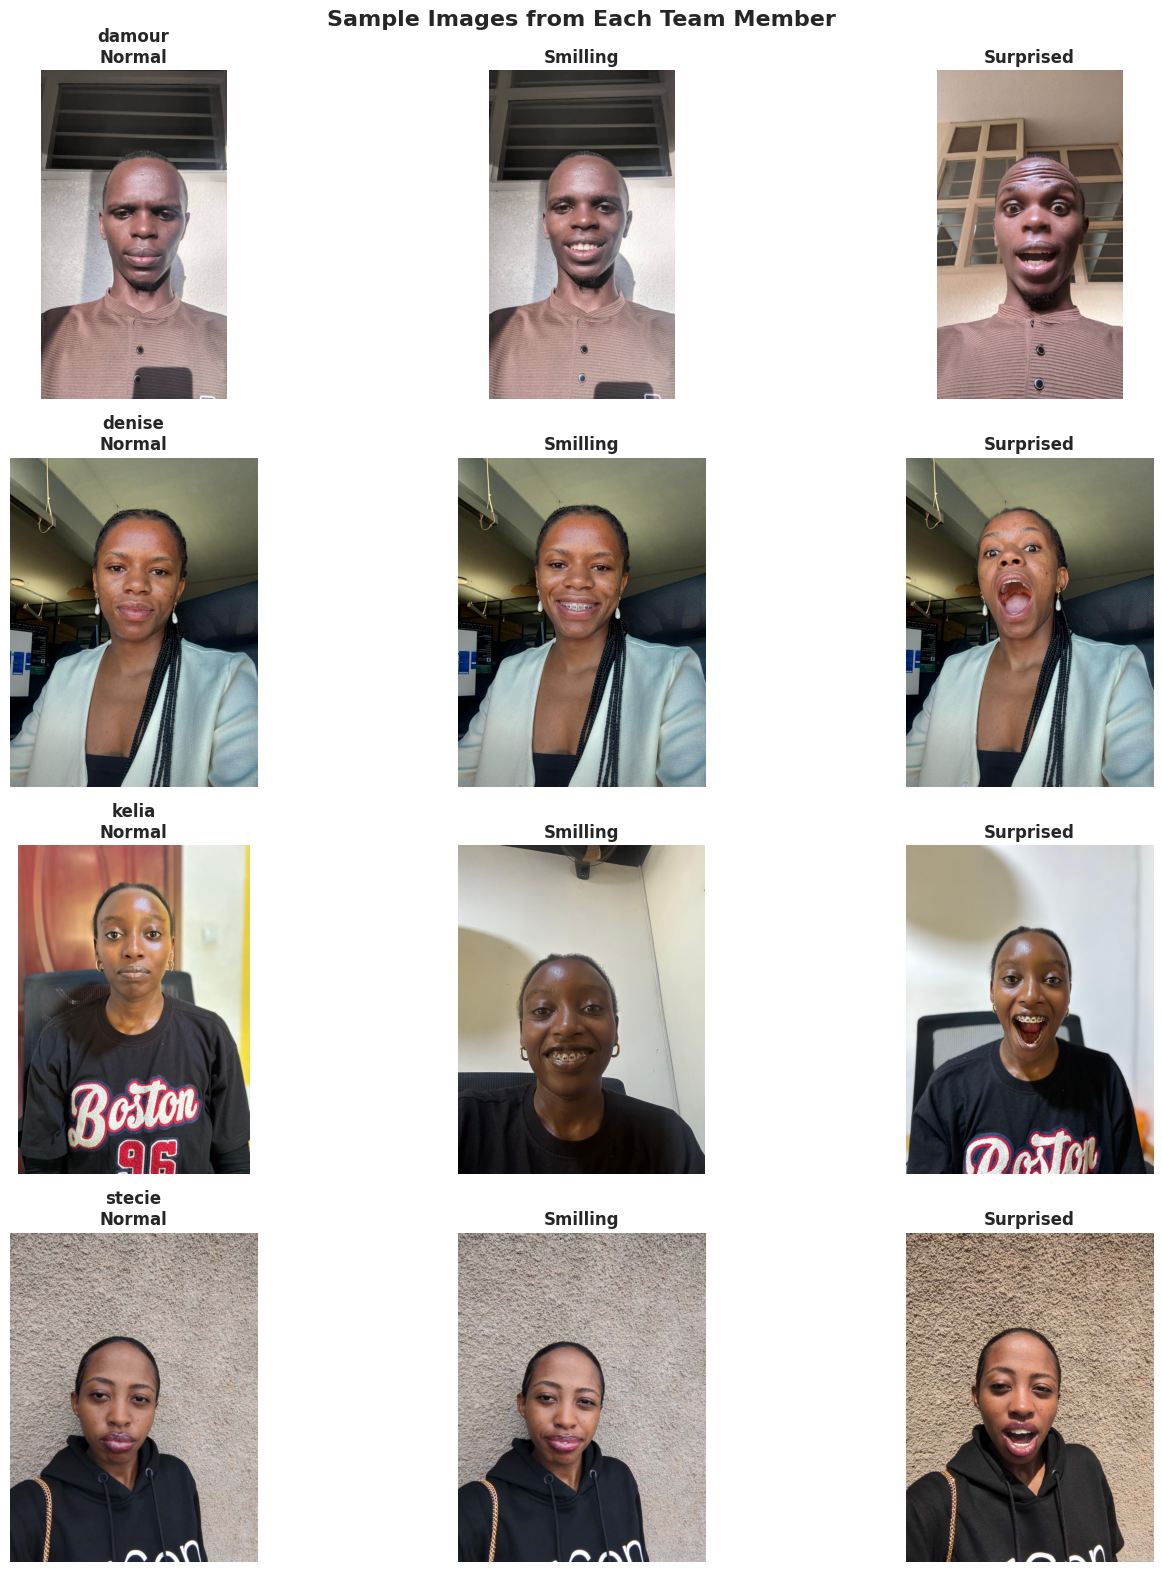

In [27]:
import cv2

# Use Config for dynamic user and expression management
base_image_dir = Config.FACE_DATA_DIR
members = Config.get_users()
expressions = Config.EXPRESSIONS

# Create a figure to display all images (dynamic rows based on number of users)
num_members = len(members)
fig, axes = plt.subplots(num_members, len(expressions), figsize=(15, num_members * 4))
fig.suptitle('Sample Images from Each Team Member', fontsize=16, fontweight='bold', y=0.98)

# Loop through each member and display their images
for row_idx, member in enumerate(members):
    member_dir = base_image_dir / member
    
    for col_idx, expression in enumerate(expressions):
        # Try different expression name variations and extensions
        img_path = None
        
        # Map of expression variations (handle typos and alternatives)
        expression_variations = [
            expression,  # Try original first
        ]
        
        # Add common variations
        if expression == 'normal':
            expression_variations.append('neutral')
        elif expression == 'smilling':
            expression_variations.extend(['smiling', 'smile'])
        
        # Try each variation with each extension
        for expr_variant in expression_variations:
            for ext in ['.jpeg', '.jpg', '.png', '.JPEG', '.JPG', '.PNG']:
                test_path = member_dir / f"{expr_variant}{ext}"
                if test_path.exists():
                    img_path = test_path
                    break
            if img_path:
                break
        
        # Read and display the image
        if img_path and img_path.exists():
            img = cv2.imread(str(img_path))
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Display the image
                axes[row_idx, col_idx].imshow(img_rgb)
                axes[row_idx, col_idx].axis('off')
                
                # Add title with member name and expression
                if col_idx == 0:
                    title = f'{member}\n{expression.capitalize()}'
                else:
                    title = expression.capitalize()
                axes[row_idx, col_idx].set_title(title, fontsize=12, fontweight='bold')
            else:
                # Image file exists but couldn't be read
                axes[row_idx, col_idx].text(0.5, 0.5, f'Error\nReading\n{img_path.name}', 
                                            ha='center', va='center', fontsize=10, color='red')
                axes[row_idx, col_idx].axis('off')
                axes[row_idx, col_idx].set_title(f'{member} - {expression}', fontsize=10)
        else:
            # If image doesn't exist, show placeholder
            axes[row_idx, col_idx].text(0.5, 0.5, 'Image\nNot Found', 
                                        ha='center', va='center', fontsize=12, color='gray')
            axes[row_idx, col_idx].axis('off')
            axes[row_idx, col_idx].set_title(f'{member} - {expression}', fontsize=10)
            
            # Debug info: print what we were looking for
            print(f"Missing: {member}/{expression} (checked: {member_dir})")

plt.tight_layout()
plt.show()

## Exploratory Data Analysis

Before training our model, we need to understand our data through summary statistics, distribution plots, and correlation analysis. This helps us spot any potential issues and ensures our dataset is ready for machine learning.

### Summary Statistics

In [28]:
# Get feature columns
feature_cols = [col for col in df.columns if col.startswith('color_hist_')]

# Create summary statistics table
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Samples',
        'Number of Users',
        'Number of Expressions',
        'Augmentation Types',
        'Feature Dimensions',
        'Missing Values',
        'Duplicate Rows',
        'Class Balance'
    ],
    'Value': [
        df.shape[0],
        df['user'].nunique(),
        df['expression'].nunique(),
        df['augmentation'].nunique(),
        len(feature_cols),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        'Balanced' if df['user'].value_counts().std() == 0 else 'Imbalanced'
    ]
})

display(summary_stats)

,Metric,Value
0,Total Samples,96
1,Number of Users,4
2,Number of Expressions,3
3,Augmentation Types,8
4,Feature Dimensions,512
5,Missing Values,0
6,Duplicate Rows,0
7,Class Balance,Balanced


### Distribution Plots

We're creating visualizations to check how our data is distributed across users, expressions, and augmentation types. This helps us verify that we have balanced classes and good coverage of different data transformations.


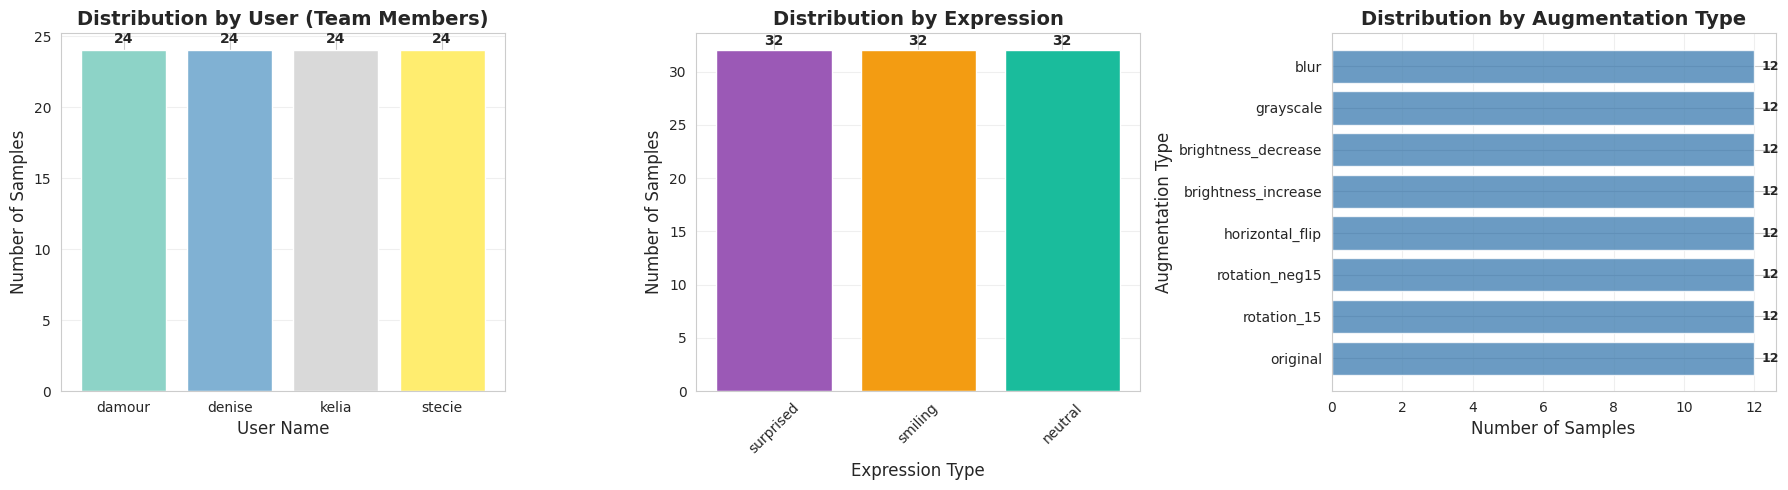

In [29]:
# Create distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: User distribution
user_counts = df['user'].value_counts().sort_index()
colors = plt.cm.Set3(np.linspace(0, 1, len(user_counts)))
axes[0].bar(user_counts.index, user_counts.values, color=colors)
axes[0].set_title('Distribution by User (Team Members)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('User Name', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(user_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=10)

# Plot 2: Expression distribution
expr_counts = df['expression'].value_counts()
axes[1].bar(expr_counts.index, expr_counts.values, color=['#9b59b6', '#f39c12', '#1abc9c'])
axes[1].set_title('Distribution by Expression', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Expression Type', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(expr_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=10)

# Plot 3: Augmentation distribution
aug_counts = df['augmentation'].value_counts()
axes[2].barh(aug_counts.index, aug_counts.values, color='steelblue', alpha=0.8)
axes[2].set_title('Distribution by Augmentation Type', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Samples', fontsize=12)
axes[2].set_ylabel('Augmentation Type', fontsize=12)
axes[2].grid(axis='x', alpha=0.3)
for i, v in enumerate(aug_counts.values):
    axes[2].text(v + 0.2, i, str(v), va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Feature Analysis

We're analyzing our feature distributions to identify any outliers and understand how feature values vary across different users. This analysis helps us determine if our features are discriminative enough for classification.


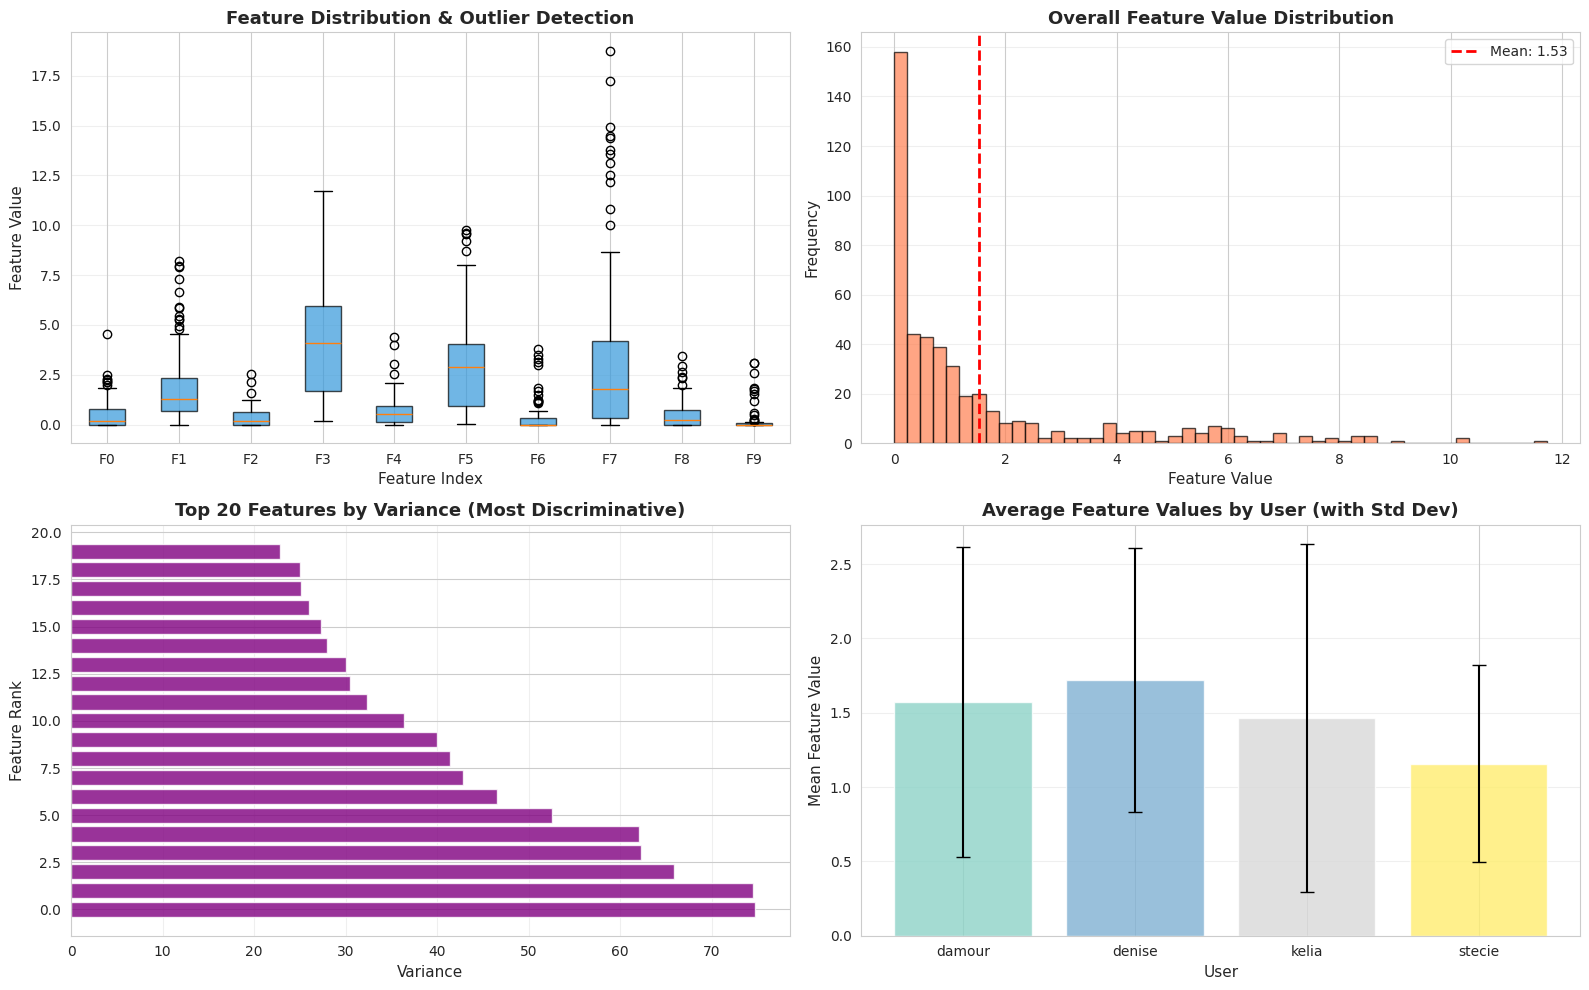

In [30]:
# Sample features for visualization
np.random.seed(42)
sample_features = np.random.choice(feature_cols, 20, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Box plot for outlier detection
bp = axes[0, 0].boxplot([df[col].values for col in sample_features[:10]], 
                         labels=[f'F{i}' for i in range(10)],
                         patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.7)
axes[0, 0].set_title('Feature Distribution & Outlier Detection', 
                      fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Feature Index', fontsize=11)
axes[0, 0].set_ylabel('Feature Value', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Distribution histogram
sample_data = df[sample_features[:5]].values.flatten()
axes[0, 1].hist(sample_data, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Overall Feature Value Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Feature Value', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].axvline(sample_data.mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {sample_data.mean():.2f}')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Feature variance across samples
feature_variance = df[feature_cols].var().sort_values(ascending=False)[:20]
axes[1, 0].barh(range(len(feature_variance)), feature_variance.values, 
                color='purple', alpha=0.8)
axes[1, 0].set_title('Top 20 Features by Variance (Most Discriminative)', 
                      fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Variance', fontsize=11)
axes[1, 0].set_ylabel('Feature Rank', fontsize=11)
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Feature statistics by user
user_means = df.groupby('user')[feature_cols].mean().mean(axis=1)
user_stds = df.groupby('user')[feature_cols].std().mean(axis=1)
x_pos = np.arange(len(user_means))
colors = plt.cm.Set3(np.linspace(0, 1, len(user_means)))
axes[1, 1].bar(x_pos, user_means.values, yerr=user_stds.values, 
               color=colors, capsize=5, alpha=0.8)
axes[1, 1].set_title('Average Feature Values by User (with Std Dev)', 
                      fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('User', fontsize=11)
axes[1, 1].set_ylabel('Mean Feature Value', fontsize=11)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(user_means.index)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Correlation Analysis

We're examining which features are most strongly correlated with user identity to understand which parts of our VGG16 embeddings are most useful for distinguishing between different people. This helps us understand what the model is learning from.


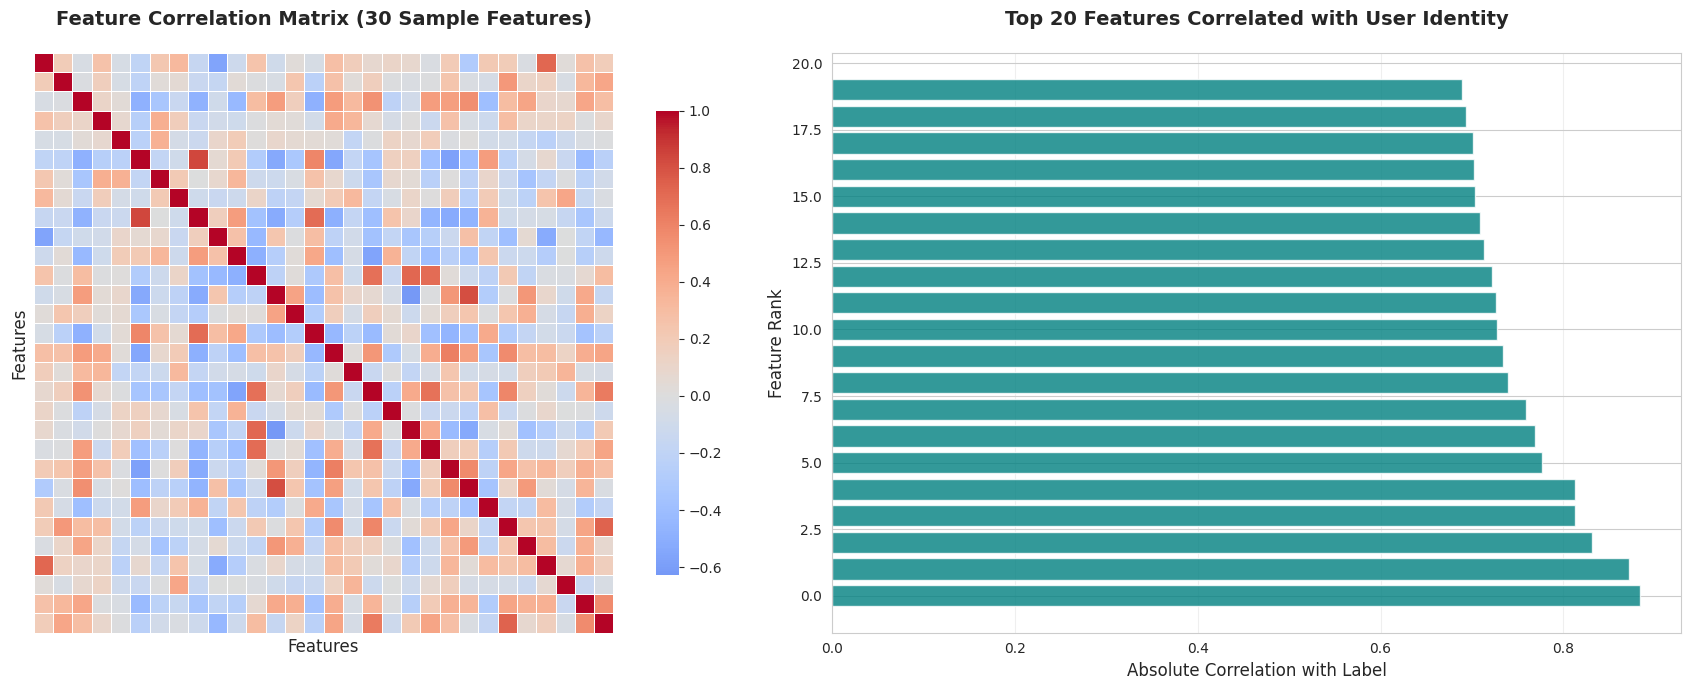

In [31]:
# Sample features for correlation analysis
sample_features_corr = np.random.choice(feature_cols, 30, replace=False)
correlation_matrix = df[sample_features_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Correlation heatmap
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title('Feature Correlation Matrix (30 Sample Features)', 
                   fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Features', fontsize=12)
axes[0].set_ylabel('Features', fontsize=12)

# Plot 2: Correlation with target variable
feature_label_corr = df[feature_cols].corrwith(df['label']).abs().sort_values(ascending=False)[:20]
axes[1].barh(range(len(feature_label_corr)), feature_label_corr.values, 
             color='teal', alpha=0.8)
axes[1].set_title('Top 20 Features Correlated with User Identity', 
                   fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Absolute Correlation with Label', fontsize=12)
axes[1].set_ylabel('Feature Rank', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### EDA Summary

Here's a comprehensive summary table that consolidates all the key metrics from our exploratory data analysis into one easy-to-read format. This gives us a quick overview of our dataset's characteristics.


In [32]:
# Create comprehensive EDA summary
eda_summary = pd.DataFrame({
    'Metric': [
        'Total Samples',
        'Original Images',
        'Augmentations per Image',
        'Total Features (Dimensions)',
        'Number of Users',
        'Number of Expressions',
        'Class Balance',
        'Missing Values',
        'Duplicate Rows',
        'Feature Type',
        'Feature Value Range'
    ],
    'Value': [
        df.shape[0],
        df['augmentation'].value_counts()['original'],
        df['augmentation'].nunique(),
        len(feature_cols),
        df['user'].nunique(),
        df['expression'].nunique(),
        'Balanced' if df['user'].value_counts().std() == 0 else 'Imbalanced',
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        'VGG16 Embeddings',
        f"[{df[feature_cols].min().min():.2f}, {df[feature_cols].max().max():.2f}]"
    ]
})

display(eda_summary)

,Metric,Value
0,Total Samples,96
1,Original Images,12
2,Augmentations per Image,8
3,Total Features (Dimensions),512
4,Number of Users,4
5,Number of Expressions,3
6,Class Balance,Balanced
7,Missing Values,0
8,Duplicate Rows,0
9,Feature Type,VGG16 Embeddings


## Data Preparation

We're cleaning the data by removing any missing values or duplicates, then validating that all our labels are correct before splitting the dataset into training and testing sets. This ensures our model trains on clean, properly formatted data.

### Data Cleaning

In [35]:
# Data cleaning and validation
# Step 1: Handle missing values
if df.isnull().sum().sum() > 0:
    df = df.dropna()

# Step 2: Remove duplicates
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

# Step 3: Validate class labels using dynamic Config mapping
users = Config.get_users()
label_mapping = Config.get_label_mapping(users)
validation_results = []
for user, expected_label in label_mapping.items():
    actual_labels = df[df['user'] == user]['label'].unique()
    is_valid = len(actual_labels) == 1 and actual_labels[0] == expected_label
    validation_results.append({
        'User': user,
        'Expected Label': expected_label,
        'Actual Label': actual_labels[0] if len(actual_labels) == 1 else 'Multiple',
        'Status': 'Valid' if is_valid else 'Invalid'
    })

validation_df = pd.DataFrame(validation_results)
display(validation_df)


,User,Expected Label,Actual Label,Status
0,damour,0,0,Valid
1,denise,1,1,Valid
2,kelia,2,2,Valid
3,stecie,3,3,Valid


### Train-Test Split

We're splitting our data into training and testing sets using an 80-20 split with stratification to ensure each class is proportionally represented in both sets. This gives us a fair evaluation of our model's performance.


In [36]:
# Separate features and labels
X = df[feature_cols].values
y = df['label'].values

# Stratified train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create split summary table
split_summary = pd.DataFrame({
    'Dataset': ['Training', 'Testing', 'Total'],
    'Samples': [X_train.shape[0], X_test.shape[0], len(X)],
    'Percentage': [
        f"{X_train.shape[0]/len(X)*100:.1f}%",
        f"{X_test.shape[0]/len(X)*100:.1f}%",
        "100.0%"
    ]
})

display(split_summary)

,Dataset,Samples,Percentage
0,Training,76,79.2%
1,Testing,20,20.8%
2,Total,96,100.0%


### Feature Scaling

We're normalizing our features to have zero mean and unit variance using StandardScaler, which helps our Random Forest model perform better by ensuring all features are on a similar scale. The scaler is fitted on the training data and then applied to both training and test sets.

In [37]:
# Apply StandardScaler for feature normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create scaling summary table
scaling_summary = pd.DataFrame({
    'Statistic': ['Min', 'Max', 'Mean', 'Std'],
    'Before Scaling (Train)': [
        f"{X_train.min():.4f}",
        f"{X_train.max():.4f}",
        f"{X_train.mean():.4f}",
        f"{X_train.std():.4f}"
    ],
    'After Scaling (Train)': [
        f"{X_train_scaled.min():.4f}",
        f"{X_train_scaled.max():.4f}",
        f"{X_train_scaled.mean():.4f}",
        f"{X_train_scaled.std():.4f}"
    ],
    'After Scaling (Test)': [
        f"{X_test_scaled.min():.4f}",
        f"{X_test_scaled.max():.4f}",
        f"{X_test_scaled.mean():.4f}",
        f"{X_test_scaled.std():.4f}"
    ]
})

display(scaling_summary)

,Statistic,Before Scaling (Train),After Scaling (Train),After Scaling (Test)
0,Min,0.0000,-2.6680,-2.4252
1,Max,40.6439,8.6603,24.5336
2,Mean,1.4855,0.0000,-0.0111
3,Std,2.8973,0.9990,1.0941


## Train the Model

We're training a Random Forest classifier with 100 trees, which should work well with our 512-dimensional feature set. The model learns to distinguish between different team members based on the VGG16 embeddings we extracted from their images.

In [38]:
# Initialize model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# Train model
start_time = time.time()
model.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

# Get class names dynamically from Config
target_names = Config.get_users()

# Create model configuration table
model_config = pd.DataFrame({
    'Parameter': ['Algorithm', 'Number of Trees', 'Max Depth', 'Features Used', 'Classes', 'Training Time (s)'],
    'Value': [
        'Random Forest',
        model.n_estimators,
        model.max_depth,
        model.n_features_in_,
        len(model.classes_),
        f"{training_time:.2f}"
    ]
})

display(model_config)

,Parameter,Value
0,Algorithm,Random Forest
1,Number of Trees,100
2,Max Depth,20
3,Features Used,512
4,Classes,4
5,Training Time (s),0.37


## Evaluation

Now we're evaluating how well our trained model performs by generating predictions on both the training and test sets. We'll measure accuracy, F1-score, and log loss to get a comprehensive view of the model's performance.

### Generate Predictions

In [39]:
# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_train_proba = model.predict_proba(X_train_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

### Calculate Metrics

We're computing a comprehensive set of metrics including accuracy, precision, recall, F1-score, and log loss to thoroughly evaluate our model's performance. These metrics give us different perspectives on how well the model identifies each team member.

In [40]:
# Calculate all required metrics
metrics = {
    'train': {
        'accuracy': accuracy_score(y_train, y_train_pred),
        'precision': precision_score(y_train, y_train_pred, average='weighted'),
        'recall': recall_score(y_train, y_train_pred, average='weighted'),
        'f1_weighted': f1_score(y_train, y_train_pred, average='weighted'),
        'f1_macro': f1_score(y_train, y_train_pred, average='macro'),
        'log_loss': log_loss(y_train, y_train_proba)
    },
    'test': {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred, average='weighted'),
        'recall': recall_score(y_test, y_test_pred, average='weighted'),
        'f1_weighted': f1_score(y_test, y_test_pred, average='weighted'),
        'f1_macro': f1_score(y_test, y_test_pred, average='macro'),
        'log_loss': log_loss(y_test, y_test_proba)
    }
}

### Performance Table

Here's a summary table showing all the main performance metrics for both our training and test sets. This makes it easy to compare how well the model performs on seen versus unseen data.

In [41]:
# Create comprehensive metrics table
metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 
               'F1-Score (Weighted)', 'F1-Score (Macro)', 'Log Loss'],
    'Training Set': [
        f"{metrics['train']['accuracy']:.4f} ({metrics['train']['accuracy']*100:.2f}%)",
        f"{metrics['train']['precision']:.4f}",
        f"{metrics['train']['recall']:.4f}",
        f"{metrics['train']['f1_weighted']:.4f}",
        f"{metrics['train']['f1_macro']:.4f}",
        f"{metrics['train']['log_loss']:.4f}"
    ],
    'Testing Set': [
        f"{metrics['test']['accuracy']:.4f} ({metrics['test']['accuracy']*100:.2f}%)",
        f"{metrics['test']['precision']:.4f}",
        f"{metrics['test']['recall']:.4f}",
        f"{metrics['test']['f1_weighted']:.4f}",
        f"{metrics['test']['f1_macro']:.4f}",
        f"{metrics['test']['log_loss']:.4f}"
    ]
})

display(metrics_table)

,Metric,Training Set,Testing Set
0,Accuracy,1.0000 (100.00%),1.0000 (100.00%)
1,Precision (Weighted),1.0000,1.0000
2,Recall (Weighted),1.0000,1.0000
3,F1-Score (Weighted),1.0000,1.0000
4,F1-Score (Macro),1.0000,1.0000
5,Log Loss,0.0533,0.1431


### Per-User Performance

We're breaking down the performance metrics for each individual team member to see how well the model identifies each person specifically. This helps us understand if the model struggles with any particular individual.

In [42]:
# Classification report - get actual users from the dataset
target_names = sorted(df['user'].unique())
report = classification_report(y_test, y_test_pred, target_names=target_names, output_dict=True)

# Create per-class table
per_class_table = pd.DataFrame({
    'User': target_names,
    'Precision': [report[name]['precision'] for name in target_names],
    'Recall': [report[name]['recall'] for name in target_names],
    'F1-Score': [report[name]['f1-score'] for name in target_names],
    'Support': [report[name]['support'] for name in target_names]
})

display(per_class_table)

,User,Precision,Recall,F1-Score,Support
0,damour,1.0,1.0,1.0,5.0
1,denise,1.0,1.0,1.0,5.0
2,kelia,1.0,1.0,1.0,5.0
3,stecie,1.0,1.0,1.0,5.0


### Confusion Matrix

The confusion matrix shows us exactly where the model makes correct predictions and where it might confuse one person for another. This visualization helps us understand the model's decision-making patterns.

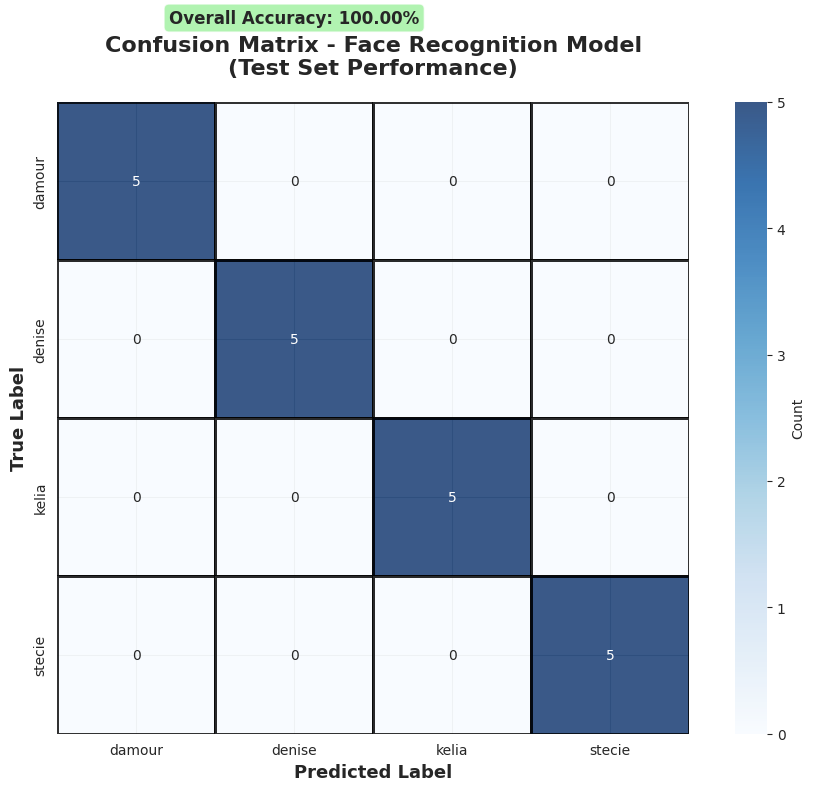

In [43]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={'label': 'Count'},
            linewidths=1, linecolor='black',
            square=True, alpha=0.8)
plt.title('Confusion Matrix - Face Recognition Model\n(Test Set Performance)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')

# Add accuracy text
plt.text(len(target_names)/2 - 0.5, -0.5, 
         f"Overall Accuracy: {metrics['test']['accuracy']*100:.2f}%",
         ha='center', fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()

### Feature Importance

We're analyzing which of the 512 VGG16 features are most important for the model's classification decisions. This helps us understand which parts of the face embeddings are most discriminative for identifying different people.

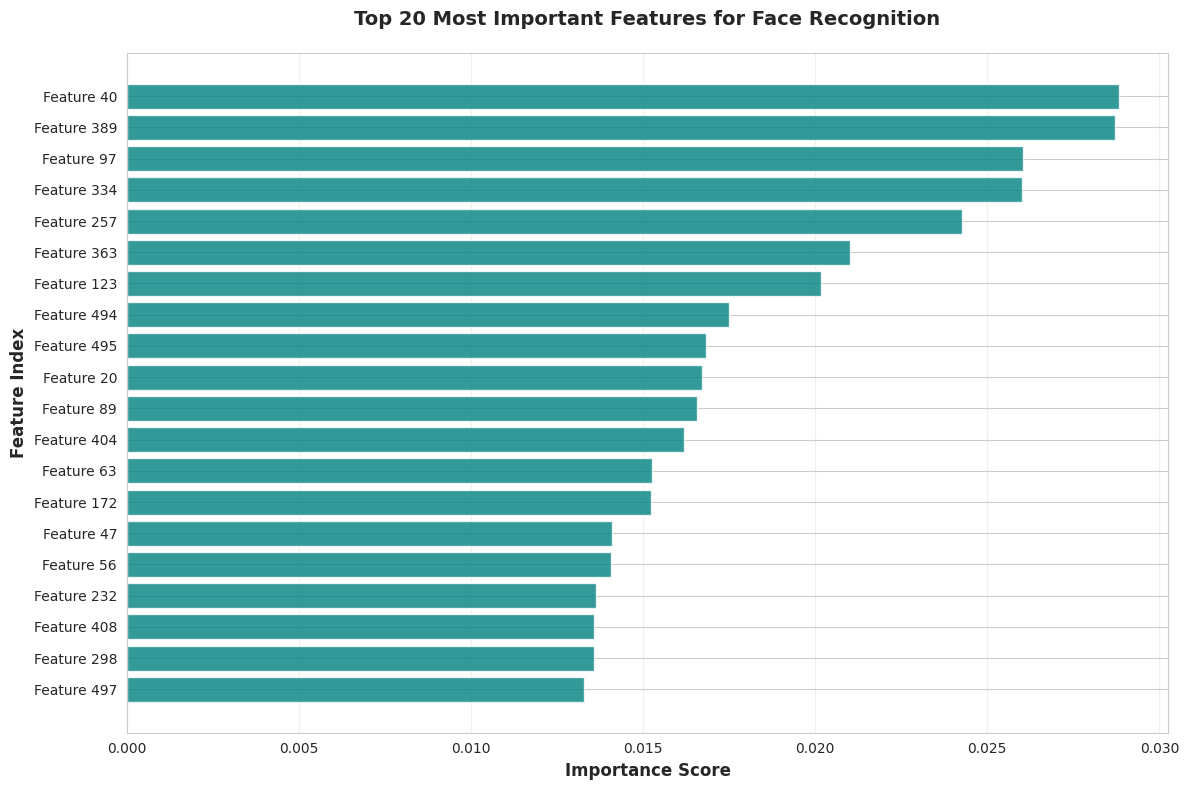

,Rank,Feature Index,Importance Score
0,1,40,0.028819
1,2,389,0.028707
2,3,97,0.026052
3,4,334,0.026013
4,5,257,0.024280


In [44]:
# Get feature importance
feature_importance = model.feature_importances_
top_20_indices = np.argsort(feature_importance)[-20:]

plt.figure(figsize=(12, 8))
plt.barh(range(20), feature_importance[top_20_indices], 
         color='teal', alpha=0.8)
plt.yticks(range(20), [f'Feature {i}' for i in top_20_indices])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature Index', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Important Features for Face Recognition',
          fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Create feature importance table
top_5_indices = top_20_indices[-5:][::-1]
importance_table = pd.DataFrame({
    'Rank': range(1, 6),
    'Feature Index': top_5_indices,
    'Importance Score': [feature_importance[idx] for idx in top_5_indices]
})

display(importance_table)

## Save Model

We're saving the trained model, scaler, and metadata to disk so we can use them later for making predictions on new images. This allows us to deploy the face recognition system without having to retrain the model every time.

In [46]:
# Create models directory
models_dir = Path('./models')
models_dir.mkdir(parents=True, exist_ok=True)

# Save model
model_path = models_dir / 'face_recognition_model.pkl'
joblib.dump(model, model_path)

# Save scaler
scaler_path = models_dir / 'face_recognition_scaler.pkl'
joblib.dump(scaler, scaler_path)

# Save metadata
metadata = {
    'model_type': 'RandomForestClassifier',
    'n_estimators': model.n_estimators,
    'max_depth': model.max_depth,
    'n_features': model.n_features_in_,
    'n_classes': len(model.classes_),
    'classes': model.classes_.tolist(),
    'class_names': target_names,
    'training_samples': X_train.shape[0],
    'test_samples': X_test.shape[0],
    'test_accuracy': float(metrics['test']['accuracy']),
    'test_f1_weighted': float(metrics['test']['f1_weighted']),
    'test_f1_macro': float(metrics['test']['f1_macro']),
    'test_log_loss': float(metrics['test']['log_loss']),
    'training_time_seconds': training_time,
    'trained_date': time.strftime('%Y-%m-%d %H:%M:%S')
}

metadata_path = models_dir / 'face_recognition_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

# Create save summary table
save_summary = pd.DataFrame({
    'Artifact': ['Model', 'Scaler', 'Metadata'],
    'File Path': [
        str(model_path),
        str(scaler_path),
        str(metadata_path)
    ],
    'File Size (KB)': [
        f"{model_path.stat().st_size / 1024:.2f}",
        f"{scaler_path.stat().st_size / 1024:.2f}",
        f"{metadata_path.stat().st_size / 1024:.2f}"
    ]
})

display(save_summary)

,Artifact,File Path,File Size (KB)
0,Model,models/face_recognition_model.pkl,128.87
1,Scaler,models/face_recognition_scaler.pkl,12.60
2,Metadata,models/face_recognition_metadata.json,0.55
